In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from  sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [39]:
df=pd.read_csv('goog.csv',thousands=',')
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    61 non-null     str    
 1   Open    61 non-null     float64
 2   High    61 non-null     float64
 3   Low     61 non-null     float64
 4   Close   61 non-null     float64
 5   Volume  61 non-null     int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 3.5 KB


In [41]:
data=df[['Close']].values

In [42]:
scaler=MinMaxScaler()
data_scaled=scaler.fit_transform(data)

In [43]:
train_size=int(len(data_scaled)*0.8)
train_data=data_scaled[:train_size]
test_data=data_scaled[train_size:]

In [56]:
time_step = 1
def create_dataset(dataset,time_step):
    X=[]
    y=[]

    for i in range(time_step, len(dataset)):
       X.append(dataset[i-time_step:i, 0])
       y.append(dataset[i,0])
    return np.array(X),np.array(y)

X_train,y_train=create_dataset(train_data,time_step)
X_test,y_test=create_dataset(test_data,time_step)



In [57]:
X_train=np.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))
X_test=np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

In [58]:
model=Sequential()
model.add(SimpleRNN(50,return_sequences=True,input_shape=(time_step,1)))
model.add(SimpleRNN(50))
model.add(Dense(1))

model.compile(optimizer='adam',loss='mean_squared_error')
model.summary()

c:\Users\HP\anaconda4\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 1, 50)          │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step - loss: 0.0965
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0378
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0096 
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0090
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0187
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0226
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0183 
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0110
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0065
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0061
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0084
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0103
Epoch 13/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0101
Epoch 14/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.0084
Epoch 15/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0063
Epoch 16/20
2/2 ━━━━━━━━━━━━━━

In [60]:
predicted=model.predict(X_test)

predicted_price=scaler.inverse_transform(predicted)
real_price=scaler.inverse_transform(y_test.reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step


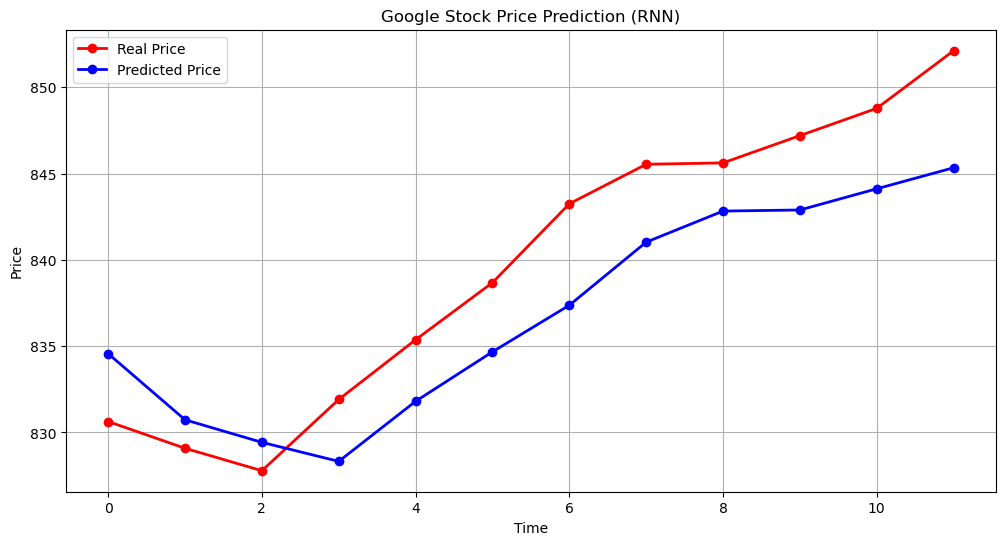

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(real_price,
         color='red',
         linewidth=2,
         marker='o',
         label='Real Price')

plt.plot(predicted_price,
         color='blue',
         linewidth=2,
         marker='o',
         label='Predicted Price')

plt.title("Google Stock Price Prediction (RNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.grid(True)
plt.legend()

plt.show()

In [65]:
from tensorflow.keras.layers import LSTM , Dropout

In [70]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(time_step,1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

c:\Users\HP\anaconda4\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [71]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [72]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=4,
    validation_data=(X_test,y_test)
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - loss: 0.2197 - val_loss: 0.6169
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1710 - val_loss: 0.4954
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1204 - val_loss: 0.3548
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0637 - val_loss: 0.2066
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0313 - val_loss: 0.0876
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0194 - val_loss: 0.0366
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0192 - val_loss: 0.0335
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0211 - val_loss: 0.0459
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0154 - val_loss: 0.0479
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0160 - val_loss: 0.0489
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0166 - val_loss: 0.0377
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.

In [73]:
# Predict on test data
predicted_lstm = model.predict(X_test)

# Convert scaled values back to original prices
predicted_price_lstm = scaler.inverse_transform(predicted_lstm)

# Convert actual test values back
real_price_lstm = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step


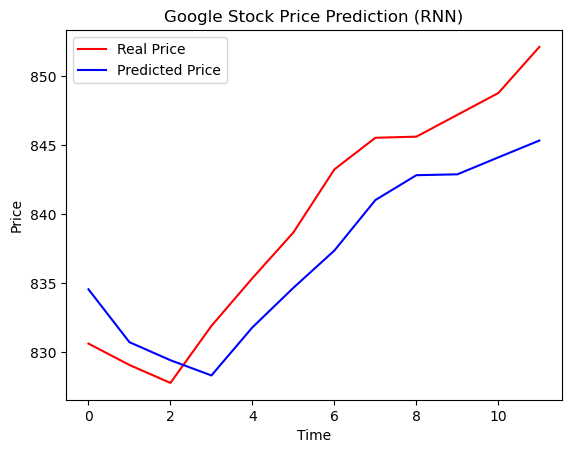

In [74]:
plt.plot(real_price, color='red', label='Real Price')
plt.plot(predicted_price, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction (RNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()